In [1]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import random
import time
import os
from joblib import Parallel, delayed

from src.model import Nonneg_dagma, MetMulDagma, MetMulColide
import src.utils as utils

SEED = 0 #10
N_CPUS = os.cpu_count()

PATH_SACHS = './datasets/sachs/'
DATASET = "SYNTH"  # SYNTH, SACHS

np.random.seed(SEED)
random.seed(SEED)

In [3]:
def get_lamb_value(n_nodes, n_samples, times=1):
    return np.sqrt(np.log(n_nodes) / n_samples) * times 

def compute_errsW(W_seq, A):
    errs = np.zeros(len(W_seq))
    norm_A = la.norm(A)
    for i, W_est in enumerate(W_seq):
        errs[i] = (la.norm(A - W_est)/norm_A)**2
    
    return errs

def plot_result_Sigma(Sig_true, Sig_est, plot_matrices=True):
    fro_err = utils.compute_norm_sq_err(Sig_true, Sig_est)
        
    print(f'Err: {fro_err:.3f}')

    if plot_matrices:
        plt.figure(figsize=(8, 8))
        plt.subplot(1,2,1)
        plt.imshow(np.diag(Sig_true))
        plt.colorbar()
        plt.title("Sigma true")
        plt.subplot(1,2,2)
        plt.imshow(np.diag(Sig_est))
        plt.colorbar()
        plt.title("Sigma est")

def plot_result(A_true, A_est, thr, plot_matrices=True):
    A_est_bin = utils.to_bin(A_est, thr)
    A_true_bin = utils.to_bin(A_true, thr)

    fro_err = utils.compute_norm_sq_err(A_true, A_est)
    fro_err_bin = utils.compute_norm_sq_err(A_true_bin, A_est_bin)
    sdh, _, _ = utils.count_accuracy(A_true_bin, A_est_bin)
    fscore = f1_score(A_true_bin.flatten(), A_est_bin.flatten())

    print(f'Err: {fro_err:.3f}  -  Err bin: {fro_err_bin:.3f}  -  shd: {sdh}  -  fscore: {fscore:.3f}')

    if plot_matrices:
        plt.figure(figsize=(8, 8))
        plt.subplot(2,2,1)
        plt.imshow(A_true)
        plt.colorbar()
        plt.title("A true")
        plt.subplot(2,2,2)
        plt.imshow(A_est)
        plt.colorbar()
        plt.title("A est")
        plt.subplot(2,2,3)
        plt.imshow(A_true_bin)
        plt.colorbar()
        plt.title("A true bin")
        plt.subplot(2,2,4)
        plt.imshow(A_est_bin)
        plt.colorbar()
        plt.title("A est bin")

def plot_convergence(model, var_true, var_name='W'):
    if var_name == 'Sigma':
        var_seq = model.seq_Sig
        var_diff = model.diff_Sig
    else:
        var_seq = model.seq_W
        var_diff = model.diff_W

    errs_var = compute_errsW(var_seq, var_true)

    plt.figure(figsize=(12, 4))
    plt.subplot(1,3,1)
    plt.semilogy(var_diff)
    plt.grid(True)
    plt.title(f'Convergence of {var_name}')
    plt.subplot(1,3,2)
    plt.semilogy(errs_var)
    plt.grid(True)
    plt.title(f'Error of {var_name}')
    plt.subplot(1,3,3)
    plt.semilogy(model.acyclicity)
    plt.grid(True)
    plt.title('Acyclicity')
    plt.tight_layout()

# Generate data

In [4]:
# DAG parameters
N = 100
g_type = 'er'
edges = N*4
edge_type = 'positive'  # Options: binary, positive, weighted
w_range = (.5, 1)  #(.3, .9)
norm_x = False
M = 1000 # 1000 #500
noise_type = "normal" # ("normal", "exp", "gumbel", "laplace")
variance = 1 # 1/np.sqrt(N)
Sigma = np.sqrt(variance)*np.ones(N)

if DATASET == "SACHS":
    A = np.load(PATH_SACHS + "sachs_A_matrix.npy")
    X = np.load(PATH_SACHS + "sachs_X.npy")
    M, N = X.shape
else:
    A, _, X = utils.simulate_sem(N, M, g_type, edges, permute=False, edge_type=edge_type,
                                w_range=w_range, noise_type=noise_type, var=variance)

if norm_x:
    X = X/la.norm(X, axis=1, keepdims=True)

print(f'Mean degree: {(A.sum(axis=0).mean()):2f}')
print('Mean norm of X:', la.norm(X, axis=1).mean())
print('Fidelity error:', 1/M*la.norm(X - X @ A, 'fro')**2)



Mean degree: 3.166162
Mean norm of X: 149.1413079899974
Fidelity error: 99.6540684461177


5003


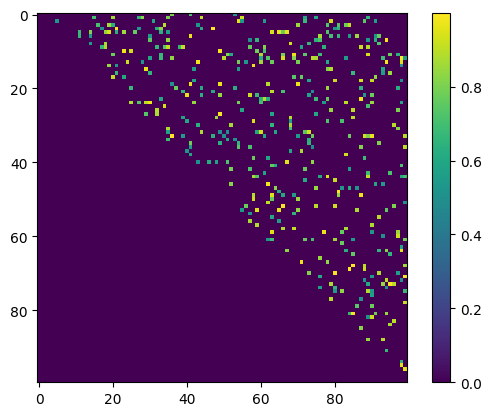

In [5]:
plt.imshow(A)
plt.colorbar()

cont = 0
for i in range(10000):
    x = np.random.randn(N,1)
    # suma = x.T @ (np.eye(N) + A) @ x
    suma = x.T @ (A) @ x
    cont += 1 if suma < -1e-6 else 0

print(cont)

# Algorithms with LogDet Acyclicity

## Method of Multipliers Algorithms

### MM + Fista

In [33]:
## Second set of hyperparams N = 50
lamb = get_lamb_value(N, M, 2e-1)
# ER
# args = {'stepsize': 1e-5, 'alpha_0': .01, 'rho_0': .01, 's': 1, 'lamb': lamb, 'iters_in': 5000,
#             'iters_out': 50, 'tol': 1e-6, 'beta': 1.5, 'verb': True}
args = {'stepsize': 1e-5, 'alpha_0': .01, 'rho_0': .01, 's': 1, 'lamb': lamb, 'iters_in': 10000,
            'iters_out': 50, 'tol': 1e-6, 'beta': 1.5, 'verb': True}

print('lamb:', lamb)

t_i = time.time()
model = MetMulDagma(acyclicity='logdet', primal_opt='fista', restart=True)
A_est = model.fit(X, **args, track_seq=True, center=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
print('Mean est value:', A_est.mean())
plot_convergence(model, A, var_name="W")
plot_result(A, A_est, thr, plot_matrices=True)

lamb: 0.013572280848830224
- 1/50. Diff: 0.000016 | Acycl: 10.729002 | Rho: 0.015 - Alpha: 0.117 - Step: 0.0000
- 2/50. Diff: 0.000002 | Acycl: 7.958818 | Rho: 0.022 - Alpha: 0.237 - Step: 0.0000
- 3/50. Diff: 0.000002 | Acycl: 5.018618 | Rho: 0.034 - Alpha: 0.350 - Step: 0.0000
- 4/50. Diff: 0.000004 | Acycl: 2.543186 | Rho: 0.051 - Alpha: 0.435 - Step: 0.0000


KeyboardInterrupt: 

### MM + Adam

lamb: 0.013572280848830224
- 1/10. Diff: 0.000089 | Acycl: 3.174373 | Rho: 0.150 - Alpha: 0.417 - Step: 0.0050
Negative acyclicity. Projecting and reducing stepsize to:  0.0025
- 2/10. Diff: 0.000059 | Acycl: 0.652003 | Rho: 0.150 - Alpha: 0.515 - Step: 0.0025
- 3/10. Diff: 0.000001 | Acycl: 0.194701 | Rho: 0.225 - Alpha: 0.544 - Step: 0.0025
- 4/10. Diff: 0.000001 | Acycl: 0.093925 | Rho: 0.338 - Alpha: 0.566 - Step: 0.0025
- 5/10. Diff: 0.000001 | Acycl: 0.047350 | Rho: 0.506 - Alpha: 0.582 - Step: 0.0025
- 6/10. Diff: 0.000000 | Acycl: 0.027542 | Rho: 0.759 - Alpha: 0.595 - Step: 0.0025
- 7/10. Diff: 0.000000 | Acycl: 0.017435 | Rho: 1.139 - Alpha: 0.609 - Step: 0.0025
- 8/10. Diff: 0.000000 | Acycl: 0.013197 | Rho: 1.709 - Alpha: 0.624 - Step: 0.0025
- 9/10. Diff: 0.000000 | Acycl: 0.009606 | Rho: 2.563 - Alpha: 0.640 - Step: 0.0025
- 10/10. Diff: 0.000000 | Acycl: 0.008967 | Rho: 3.844 - Alpha: 0.663 - Step: 0.0025
Solved in 40.361542 seconds
Mean est value: 0.031379614761237073
E

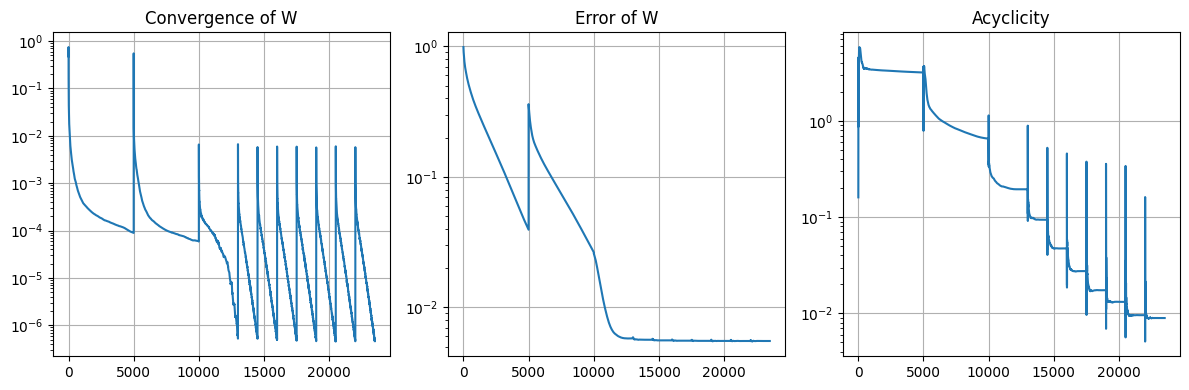

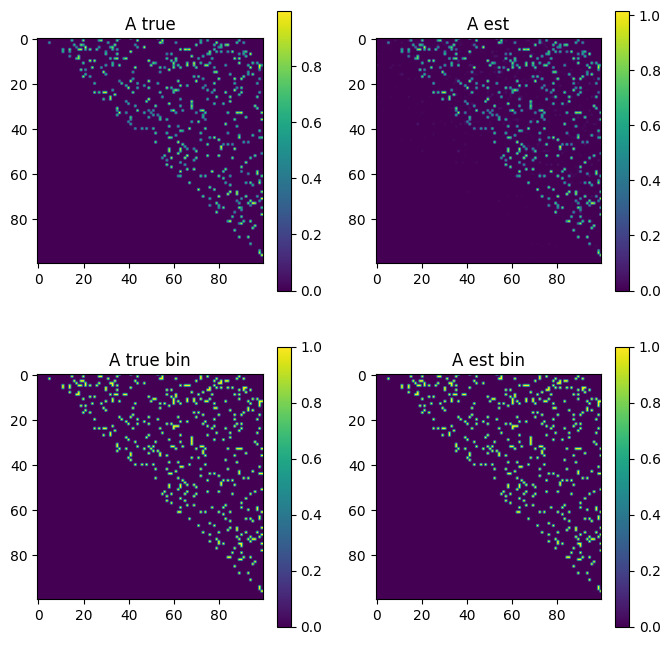

In [ ]:
## Second set of hyperparams N = 50
lamb = get_lamb_value(N, M, 2e-1)
# ER
args = {'stepsize': 5e-3, 'alpha_0': .1, 'rho_0': .1, 's': 1, 'lamb': lamb, 'iters_in': 5000,
            'iters_out': 10, 'tol': 1e-6, 'beta': 1.5, 'verb': True}
# SF
# args = {'stepsize': 3e-4, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': lamb, 'iters_in': 10000,
#             'iters_out': 10, 'tol': 1e-6, 'beta': 5, 'verb': True}

print('lamb:', lamb)

t_i = time.time()
model = MetMulDagma(acyclicity='logdet', primal_opt='adam')
A_est = model.fit(X, **args, track_seq=True, center=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
print('Mean est value:', A_est.mean())
plot_convergence(model, A, var_name="W")
plot_result(A, A_est, thr, plot_matrices=True)

## Nonegative CoLiDE + MoMultipliers (NV) Algorithms

### FISTA

lamb: 0.006786140424415112
Convergence achieved at iter 12001
- 1/10. Diff W: 0.000000 | Diff Sigma: 0.000000 | Acycl: 5.882719 |Rho: 0.075 - Alpha: 0.451 - Step: 0.0001
Convergence achieved at iter 13001
- 2/10. Diff W: 0.000001 | Diff Sigma: 0.000001 | Acycl: 0.609406 |Rho: 0.075 - Alpha: 0.497 - Step: 0.0001
Convergence achieved at iter 1
- 3/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.609316 |Rho: 0.113 - Alpha: 0.565 - Step: 0.0001
Convergence achieved at iter 5251
- 4/10. Diff W: 0.000001 | Diff Sigma: 0.000001 | Acycl: 0.017411 |Rho: 0.113 - Alpha: 0.567 - Step: 0.0001
Convergence achieved at iter 1
- 5/10. Diff W: 0.000000 | Diff Sigma: 0.000000 | Acycl: 0.017411 |Rho: 0.169 - Alpha: 0.570 - Step: 0.0001
Convergence achieved at iter 1
- 6/10. Diff W: 0.000000 | Diff Sigma: 0.000000 | Acycl: 0.017410 |Rho: 0.253 - Alpha: 0.575 - Step: 0.0001
Convergence achieved at iter 1
- 7/10. Diff W: 0.000000 | Diff Sigma: 0.000000 | Acycl: 0.017410 |Rho: 0.380 - Alpha: 0.581 - St

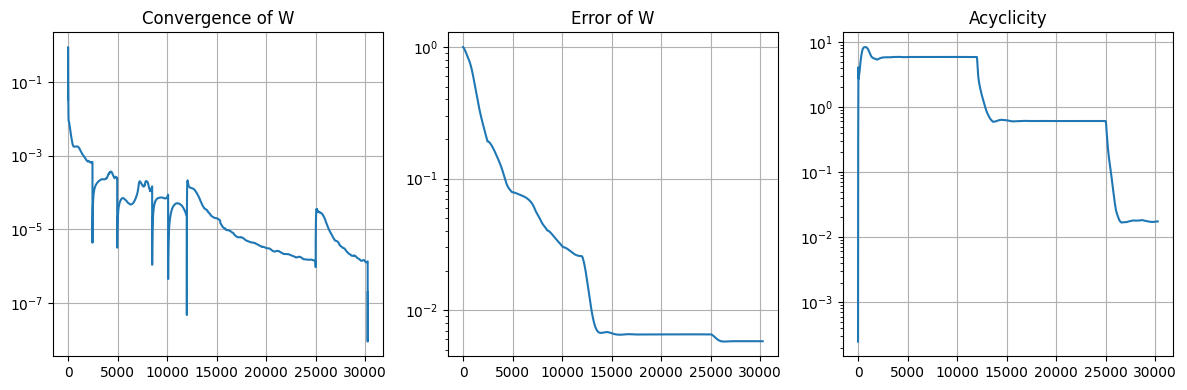

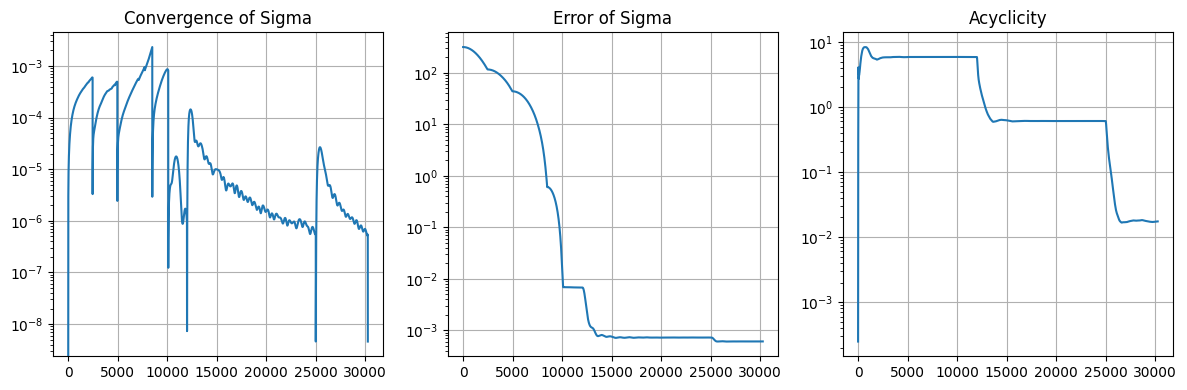

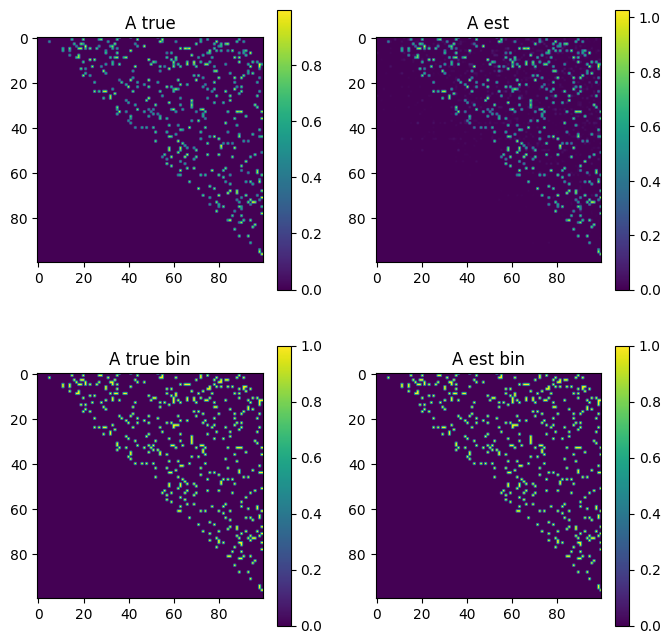

In [9]:
lamb = get_lamb_value(N, M, 1e-1)
args = {'stepsize': 5e-5, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': lamb, 'iters_in': 30000,
        'iters_out': 10, 'beta': 1.5, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='fista', restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2   
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)
# plot_result_Sigma(Sigma, Sigma_est)

### ADAM

lamb: 0.006786140424415112
- 1/10. Diff W: 0.000006 | Diff Sigma: 0.000011 | Acycl: 5.541420 |Rho: 0.100 - Alpha: 0.564 - Step: 0.0003
- 2/10. Diff W: 0.000005 | Diff Sigma: 0.000011 | Acycl: 0.022224 |Rho: 0.100 - Alpha: 0.566 - Step: 0.0003
- 3/10. Diff W: 0.000005 | Diff Sigma: 0.000009 | Acycl: 0.020015 |Rho: 0.200 - Alpha: 0.570 - Step: 0.0003
- 4/10. Diff W: 0.000004 | Diff Sigma: 0.000009 | Acycl: 0.014312 |Rho: 0.400 - Alpha: 0.576 - Step: 0.0003
- 5/10. Diff W: 0.000005 | Diff Sigma: 0.000011 | Acycl: 0.011652 |Rho: 0.800 - Alpha: 0.585 - Step: 0.0003
- 6/10. Diff W: 0.000004 | Diff Sigma: 0.000012 | Acycl: 0.008580 |Rho: 1.600 - Alpha: 0.599 - Step: 0.0003
- 7/10. Diff W: 0.000004 | Diff Sigma: 0.000014 | Acycl: 0.006894 |Rho: 3.200 - Alpha: 0.621 - Step: 0.0003
- 8/10. Diff W: 0.000004 | Diff Sigma: 0.000023 | Acycl: 0.005869 |Rho: 6.400 - Alpha: 0.659 - Step: 0.0003
- 9/10. Diff W: 0.000004 | Diff Sigma: 0.000027 | Acycl: 0.004248 |Rho: 12.800 - Alpha: 0.713 - Step: 0.0003


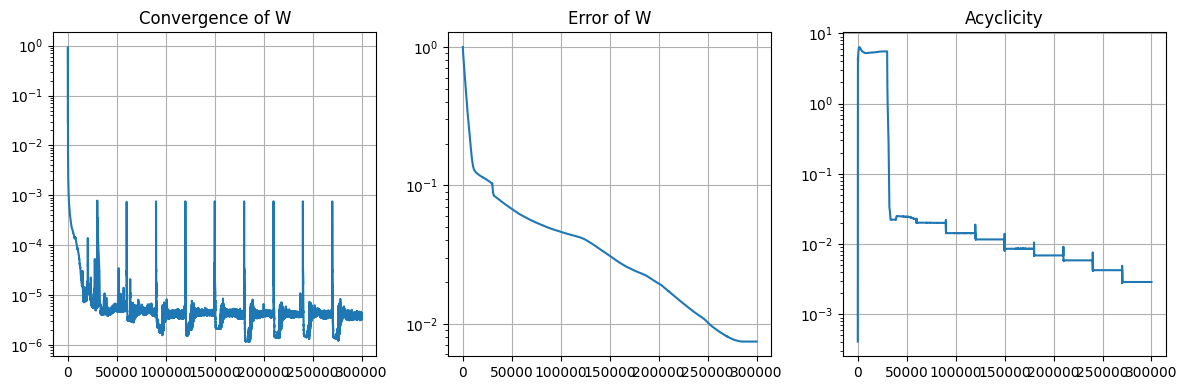

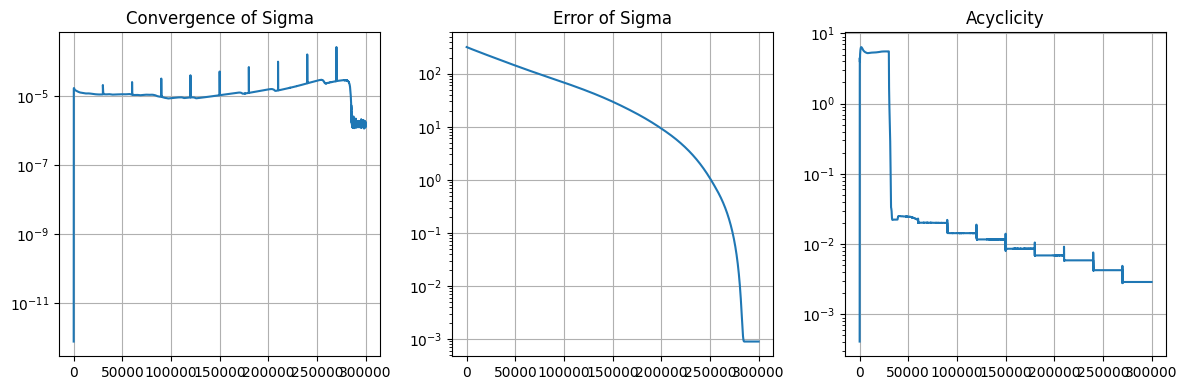

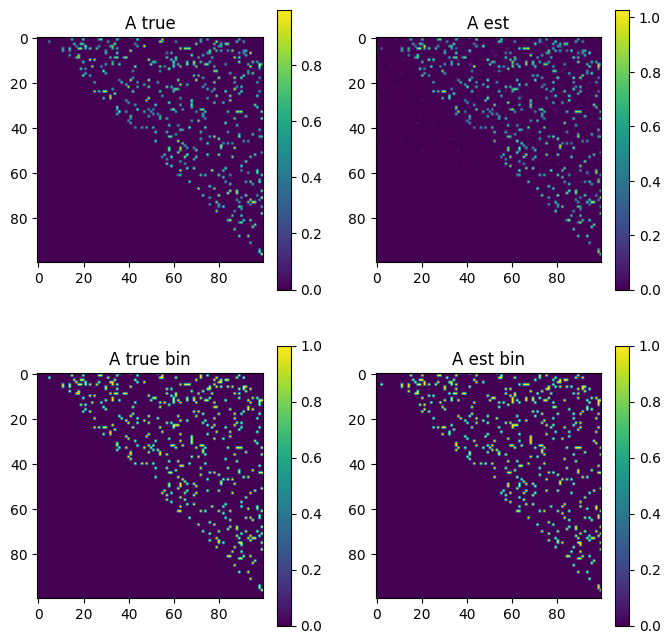

In [8]:
lamb = get_lamb_value(N, M, 1e-1)
args = {'stepsize': 3e-4, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': lamb, 'iters_in': 30000,
            'iters_out': 10, 'tol': 1e-6, 'beta': 2, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='adam', restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)

### SCA

lamb: 0.06786140424415112
Negative acyclicity. Projecting and reducing stepsize to:  0.00015
- 1/10. Diff W: 0.000020 | Diff Sigma: 0.000007 | Acycl: 1.458801 |Rho: 1.000 - Alpha: 1.959 - Step: 0.0001
- 2/10. Diff W: 0.000006 | Diff Sigma: 0.000002 | Acycl: 0.089435 |Rho: 1.000 - Alpha: 2.048 - Step: 0.0001
- 3/10. Diff W: 0.000003 | Diff Sigma: 0.000001 | Acycl: 0.054085 |Rho: 2.000 - Alpha: 2.156 - Step: 0.0001
- 4/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.044600 |Rho: 4.000 - Alpha: 2.335 - Step: 0.0001
- 5/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.041467 |Rho: 8.000 - Alpha: 2.667 - Step: 0.0001
- 6/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.024025 |Rho: 16.000 - Alpha: 3.051 - Step: 0.0001
- 7/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.010516 |Rho: 32.000 - Alpha: 3.387 - Step: 0.0001
- 8/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.010354 |Rho: 64.000 - Alpha: 4.050 - Step: 0.0001
- 9/10. Diff W: 0.000002 | Diff Sigma: 0

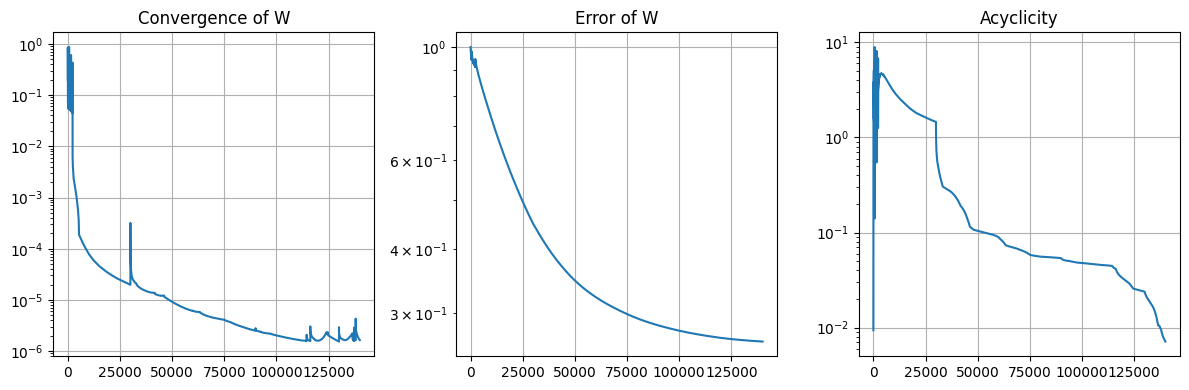

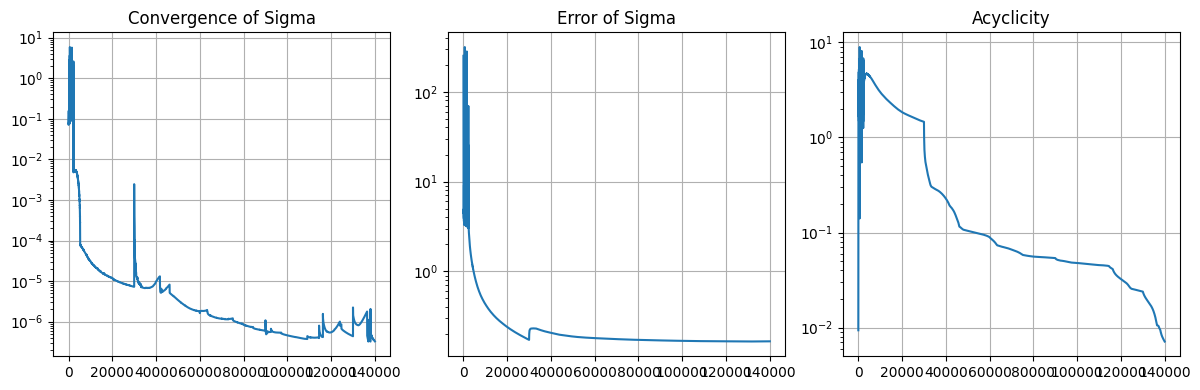

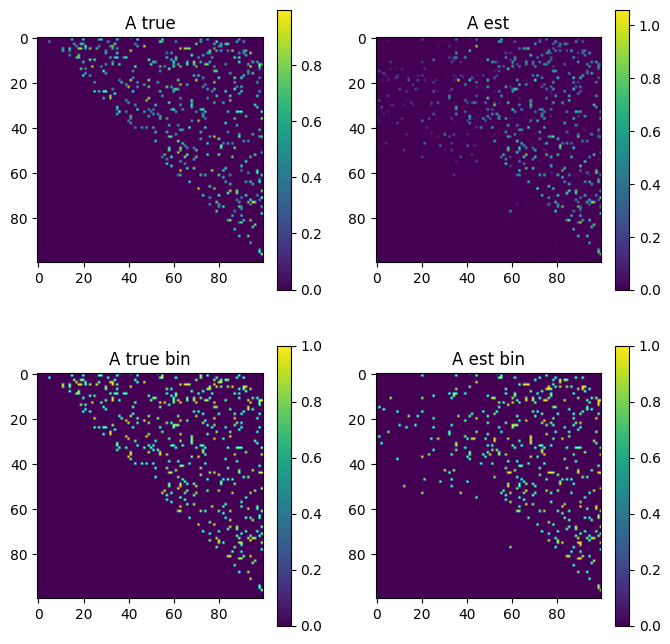

In [7]:
lamb = get_lamb_value(N, M, 1)
args = {'stepsize': 3e-4, 'alpha_0': .5, 'rho_0': .5, 's': 1, 'lamb': lamb, 'iters_in': 30000,
            'iters_out': 10, 'tol': 1e-6, 'beta': 2, 'sca_adam': False, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='sca', restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)

### SCA + Adam

lamb: 0.006786140424415112
- 1/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 5.882731 |Rho: 0.100 - Alpha: 0.598 - Step: 0.0003
- 2/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.007545 |Rho: 0.100 - Alpha: 0.599 - Step: 0.0003
- 3/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.007498 |Rho: 0.200 - Alpha: 0.601 - Step: 0.0003
- 4/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.007364 |Rho: 0.400 - Alpha: 0.603 - Step: 0.0003
- 5/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.007184 |Rho: 0.800 - Alpha: 0.609 - Step: 0.0003
- 6/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.006956 |Rho: 1.600 - Alpha: 0.620 - Step: 0.0003
- 7/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.006463 |Rho: 3.200 - Alpha: 0.641 - Step: 0.0003
- 8/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.005430 |Rho: 6.400 - Alpha: 0.676 - Step: 0.0003
- 9/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.004033 |Rho: 12.800 - Alpha: 0.727 - Step: 0.0003


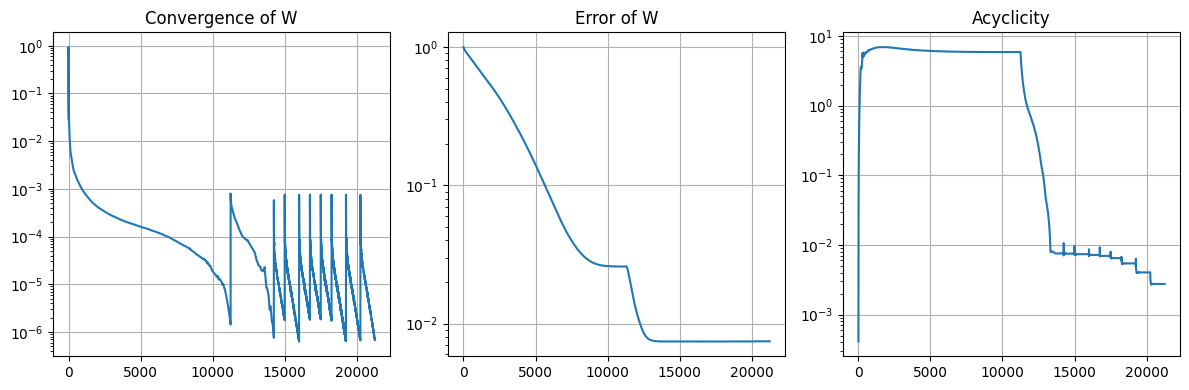

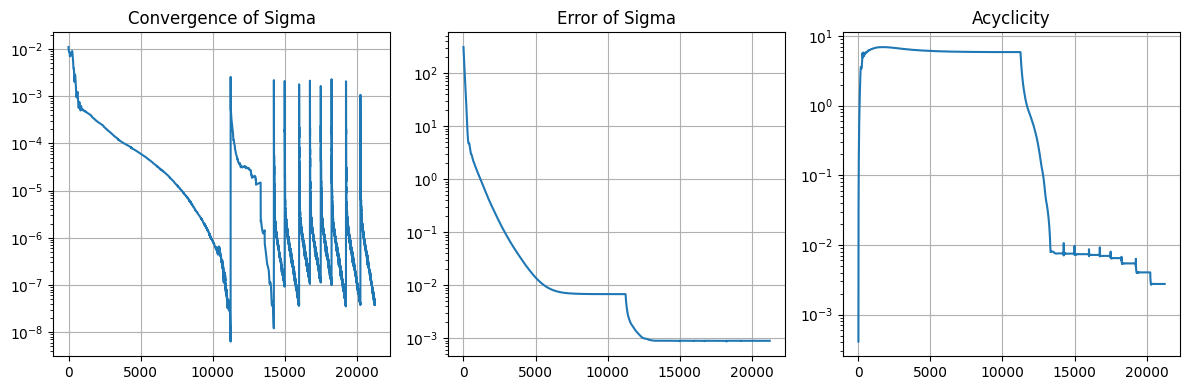

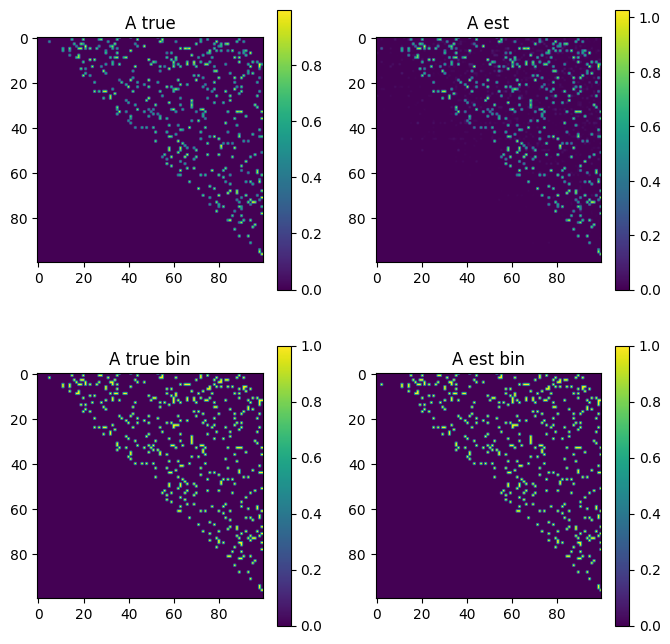

In [6]:
lamb = get_lamb_value(N, M, .1)
args = {'stepsize': 3e-4, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': lamb, 'iters_in': 30000,
            'iters_out': 10, 'tol': 1e-6, 'beta': 2, 'sca_adam': True, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='sca', restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)

## Nonegative CoLiDE + MoMultipliers (EV) Algorithms

### FISTA

In [ ]:
lamb = get_lamb_value(N, M, 1e-1)
args = {'stepsize': 5e-5, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': lamb, 'iters_in': 30000,
        'iters_out': 10, 'beta': 1.5, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='fista', equal_var=True, restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2   
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)
# plot_result_Sigma(Sigma, Sigma_est)

lamb: 0.006786140424415112


TypeError: __init__() got an unexpected keyword argument 'equal_var'

### ADAM

lamb: 0.006786140424415112
- 1/10. Diff W: 0.000006 | Diff Sigma: 0.000011 | Acycl: 5.541420 |Rho: 0.100 - Alpha: 0.564 - Step: 0.0003
- 2/10. Diff W: 0.000005 | Diff Sigma: 0.000011 | Acycl: 0.022511 |Rho: 0.100 - Alpha: 0.566 - Step: 0.0003
- 3/10. Diff W: 0.000005 | Diff Sigma: 0.000011 | Acycl: 0.020816 |Rho: 0.200 - Alpha: 0.571 - Step: 0.0003
- 4/10. Diff W: 0.000005 | Diff Sigma: 0.000011 | Acycl: 0.015684 |Rho: 0.400 - Alpha: 0.577 - Step: 0.0003
- 5/10. Diff W: 0.000005 | Diff Sigma: 0.000011 | Acycl: 0.013957 |Rho: 0.800 - Alpha: 0.588 - Step: 0.0003
- 6/10. Diff W: 0.000006 | Diff Sigma: 0.000011 | Acycl: 0.010528 |Rho: 1.600 - Alpha: 0.605 - Step: 0.0003
- 7/10. Diff W: 0.000005 | Diff Sigma: 0.000011 | Acycl: 0.009508 |Rho: 3.200 - Alpha: 0.635 - Step: 0.0003
- 8/10. Diff W: 0.000006 | Diff Sigma: 0.000011 | Acycl: 0.005754 |Rho: 6.400 - Alpha: 0.672 - Step: 0.0003
- 9/10. Diff W: 0.000006 | Diff Sigma: 0.000011 | Acycl: 0.004212 |Rho: 12.800 - Alpha: 0.726 - Step: 0.0003


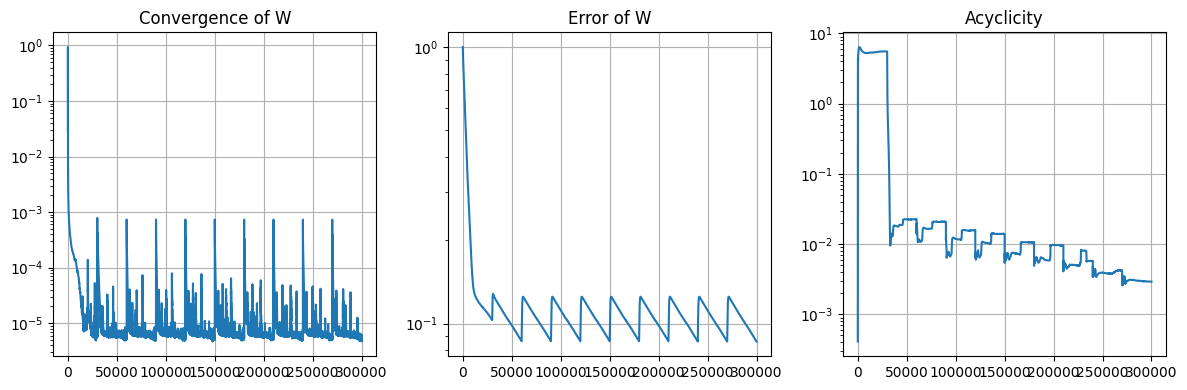

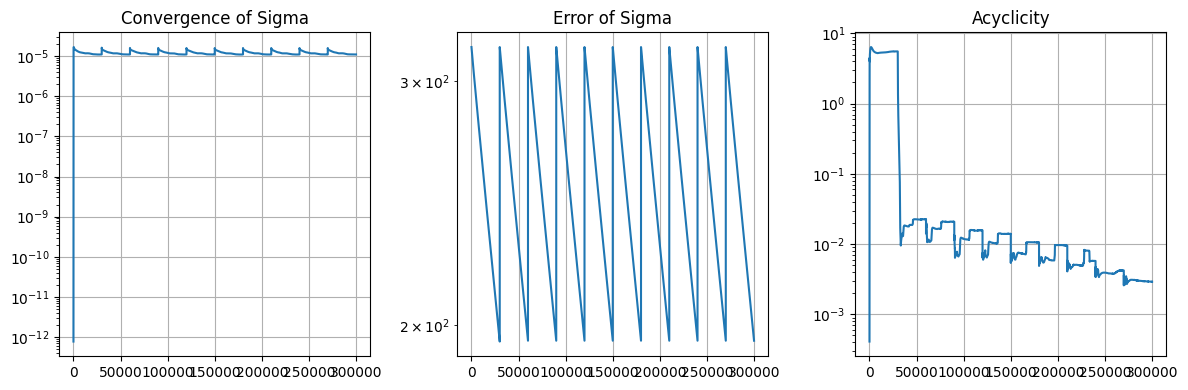

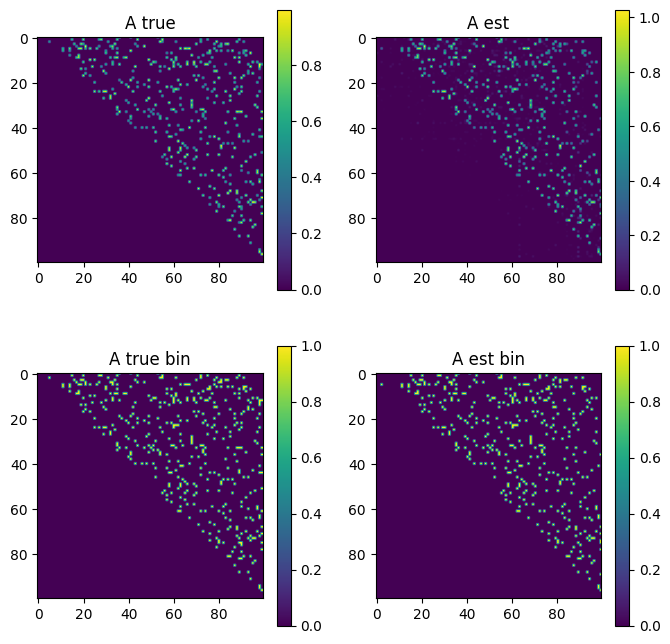

In [ ]:
lamb = get_lamb_value(N, M, 1e-1)
args = {'stepsize': 3e-4, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': lamb, 'iters_in': 30000,
            'iters_out': 10, 'tol': 1e-6, 'beta': 2, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='adam', equal_var=True, restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)

### SCA

lamb: 0.06786140424415112
Negative acyclicity. Projecting and reducing stepsize to:  0.00015
- 1/10. Diff W: 0.000020 | Diff Sigma: 0.000007 | Acycl: 1.458801 |Rho: 1.000 - Alpha: 1.959 - Step: 0.0001
- 2/10. Diff W: 0.000006 | Diff Sigma: 0.000002 | Acycl: 0.089468 |Rho: 1.000 - Alpha: 2.048 - Step: 0.0001
- 3/10. Diff W: 0.000003 | Diff Sigma: 0.000001 | Acycl: 0.054027 |Rho: 2.000 - Alpha: 2.156 - Step: 0.0001
- 4/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.044594 |Rho: 4.000 - Alpha: 2.335 - Step: 0.0001
- 5/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.041460 |Rho: 8.000 - Alpha: 2.666 - Step: 0.0001
- 6/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.024002 |Rho: 16.000 - Alpha: 3.050 - Step: 0.0001
- 7/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.010513 |Rho: 32.000 - Alpha: 3.387 - Step: 0.0001
- 8/10. Diff W: 0.000002 | Diff Sigma: 0.000000 | Acycl: 0.010358 |Rho: 64.000 - Alpha: 4.050 - Step: 0.0001
- 9/10. Diff W: 0.000002 | Diff Sigma: 0

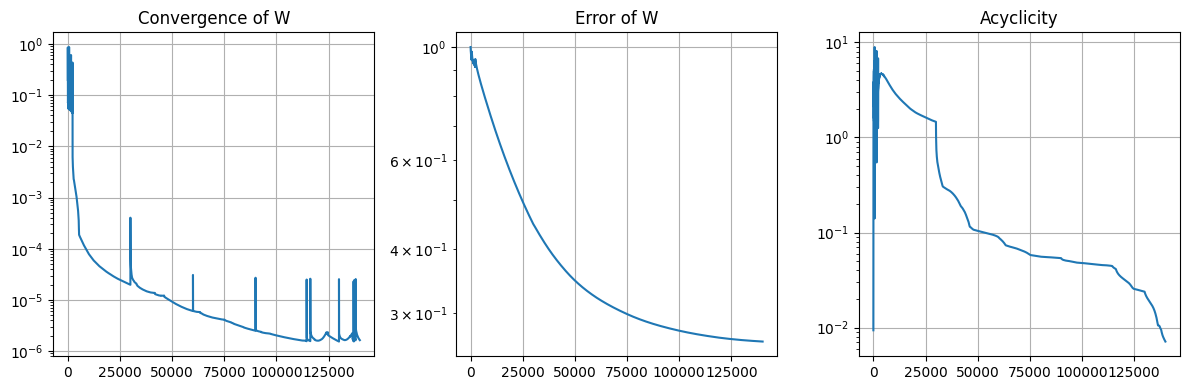

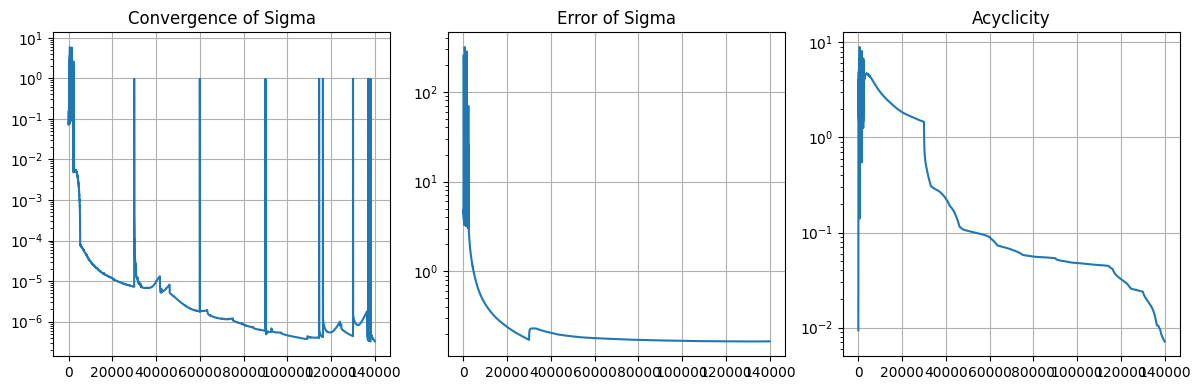

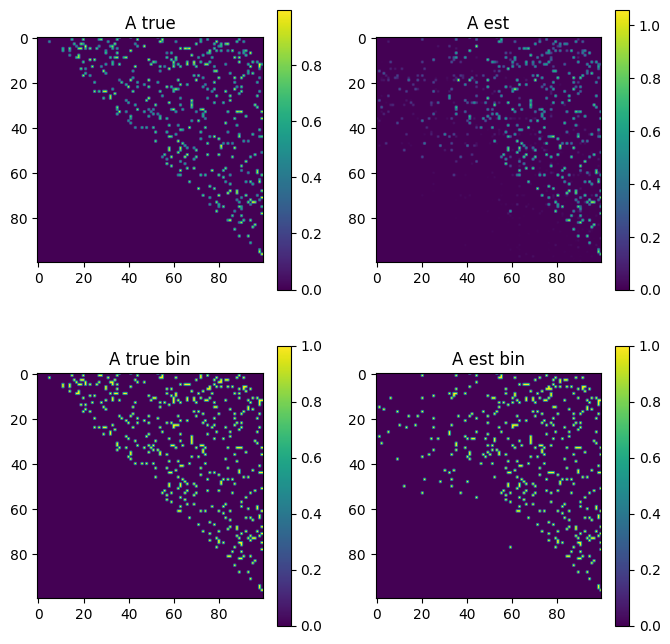

In [ ]:
lamb = get_lamb_value(N, M, 1)
args = {'stepsize': 3e-4, 'alpha_0': .5, 'rho_0': .5, 's': 1, 'lamb': lamb, 'iters_in': 30000,
            'iters_out': 10, 'tol': 1e-6, 'beta': 2, 'sca_adam': False, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='sca', equal_var=True, restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)

### SCA + Adam

lamb: 0.006786140424415112
- 1/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 5.882731 |Rho: 0.100 - Alpha: 0.598 - Step: 0.0003
- 2/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.007545 |Rho: 0.100 - Alpha: 0.599 - Step: 0.0003
- 3/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.007500 |Rho: 0.200 - Alpha: 0.601 - Step: 0.0003
- 4/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.007364 |Rho: 0.400 - Alpha: 0.603 - Step: 0.0003
- 5/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.007183 |Rho: 0.800 - Alpha: 0.609 - Step: 0.0003
- 6/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.006956 |Rho: 1.600 - Alpha: 0.620 - Step: 0.0003
- 7/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.006463 |Rho: 3.200 - Alpha: 0.641 - Step: 0.0003
- 8/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.005428 |Rho: 6.400 - Alpha: 0.676 - Step: 0.0003
- 9/10. Diff W: 0.000001 | Diff Sigma: 0.000000 | Acycl: 0.004033 |Rho: 12.800 - Alpha: 0.727 - Step: 0.0003


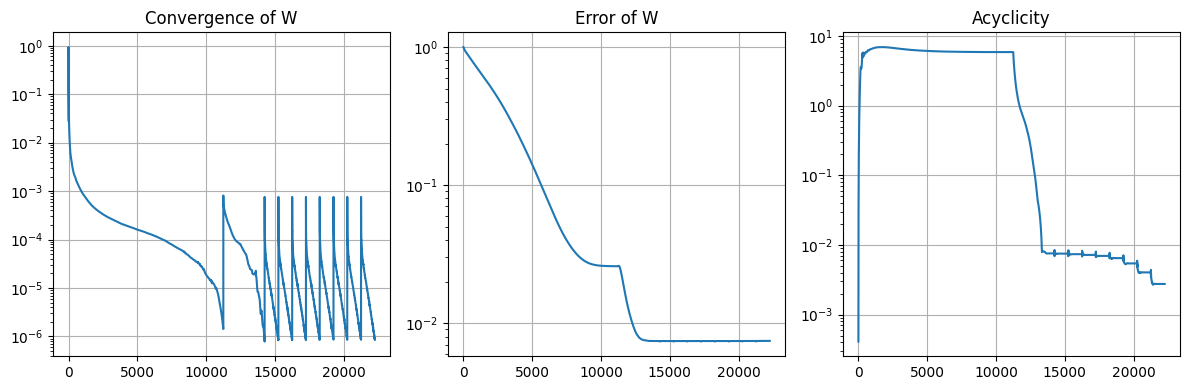

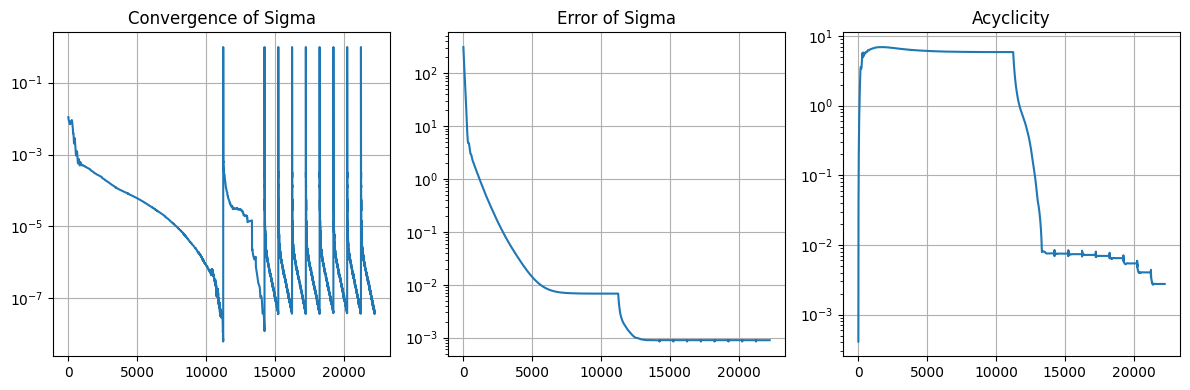

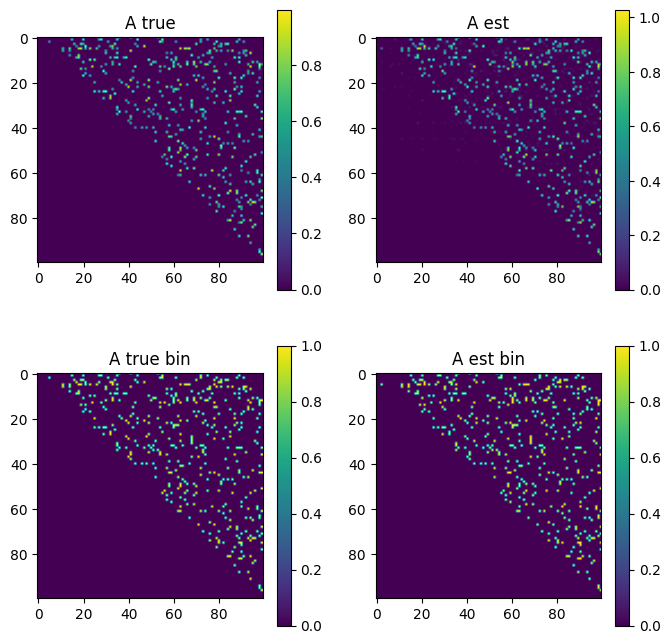

In [ ]:
lamb = get_lamb_value(N, M, .1)
args = {'stepsize': 3e-4, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': lamb, 'iters_in': 30000,
            'iters_out': 10, 'tol': 1e-6, 'beta': 2, 'sca_adam': True, 'verb': True}
# args = {'stepsize': 5e-3, 'alpha': .5, 's': 1, 'lamb': lamb, 'max_iters': 20000, 'tol': 1e-4}

print('lamb:', lamb)

t_i = time.time()
model = MetMulColide(acyclicity='logdet', primal_opt='sca', equal_var=True, restart=True)
A_est, Sigma_est = model.fit(X, **args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .2
plot_convergence(model, A, var_name="W")
plot_convergence(model, Sigma, var_name="Sigma")
plot_result(A, A_est, thr, plot_matrices=True)